# Banking Customer Activity Forecasting Using XGBoost

## 1. Introduction

### 1.1 Business Context

Understanding customer activity is important for banks seeking to monitor engagement, anticipate service demand and support operational planning. Historical transaction data can provide insights into customer behaviour and help identify patterns in banking activity over time.

This project investigates whether historical transaction activity can be used to forecast the number of active banking customers in future periods.

### 1.2 Project Objective

The primary objective is to develop and evaluate an XGBoost regression model for forecasting active customer volumes using historical transaction data.

An active customer is provisionally defined as a unique customer who performs at least one recorded transaction within a specified period. The final forecasting frequency will be determined following an assessment of the dataset's historical coverage and activity patterns.

### 1.3 Analytical Approach

The project follows an end-to-end data science workflow encompassing:

1. Data understanding and quality assessment.
2. Exploratory data analysis of customer activity and transaction patterns.
3. Time-series aggregation and feature engineering.
4. Development of baseline and XGBoost forecasting models.
5. Model evaluation using chronological validation and appropriate forecasting metrics.
6. Interpretation of forecasting results and their potential business applications.

### 1.4 Dataset

The analysis uses a publicly available synthetic banking dataset containing customer identifiers and transaction-level records.

The dataset provides an opportunity to demonstrate banking analytics and forecasting techniques without exposing confidential customer information.

As the data is synthetic, the findings should be interpreted as a demonstration of the analytical methodology rather than evidence of actual banking customer behaviour.


## 2. Data Understanding and Preparation

### 2.1 Environment Setup

The analysis is conducted in Python using Pandas and NumPy for data manipulation and numerical operations.

The initial stage focuses on loading the source files, inspecting their structure and assessing data quality before performing any transformations or modelling.


In [1]:
from pathlib import Path
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 2.2 Data Loading

The dataset consists of two CSV files: a customer table containing customer identifiers and a transaction table containing individual banking transactions.

The transaction timestamp is parsed as a timezone-aware datetime field to support accurate temporal aggregation. Selected columns are assigned appropriate data types to reduce memory usage while preserving the information required for analysis.


In [2]:
# Load the datasets
customers = pd.read_csv("customers.csv")

transactions = pd.read_csv(
    "transactions.csv",
    parse_dates=["transaction_timestamp"]
)

print("Customers:", customers.shape)
print("Transactions:", transactions.shape)

Customers: (60000, 1)
Transactions: (1000000, 8)


### 2.3 Initial Data Inspection

An initial inspection is performed to understand the structure and contents of the customer and transaction tables.

This includes examining the number of records and attributes, identifying column data types and reviewing sample observations.

Understanding the structure of the source data is necessary before defining customer activity measures, performing time-series aggregation or developing forecasting models.


In [3]:
def inspect_dataframe(df: pd.DataFrame, name: str) -> None:
    """Display the structure and a sample of a DataFrame."""

    print(f"{name.upper()}")
    print(" ")

    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

    print("\nSample records:")
    display(df.head())


inspect_dataframe(customers, "Customers")
inspect_dataframe(transactions, "Transactions")

CUSTOMERS
 
Rows: 60,000
Columns: 1

Sample records:


,customer_id
0,30001
1,30002
2,30003
3,30004
4,30005


TRANSACTIONS
 
Rows: 1,000,000
Columns: 8

Sample records:


,transaction_id,customer_id,transaction_timestamp,amount,merchant_category,is_fraud,year,month
0,500006,49108,2023-05-06 00:00:00+02:00,274.13,travel,0,2023,5
1,500010,39120,2023-05-15 00:00:00+02:00,967.29,groceries,0,2023,5
2,500018,50180,2023-05-24 00:00:00+02:00,645.61,travel,0,2023,5
3,500019,3885,2023-05-09 00:00:00+02:00,33.22,fashion,0,2023,5
4,500020,43392,2023-05-12 00:00:00+02:00,679.43,electronics,0,2023,5


In [4]:
def summarise_transaction_history(df: pd.DataFrame) -> pd.Series:
    """Summarise the temporal coverage and customer activity."""

    timestamps = df["transaction_timestamp"]

    return pd.Series({
        "First transaction": timestamps.min(),
        "Last transaction": timestamps.max(),
        "Distinct transaction dates": timestamps.dt.date.nunique(),
        "Distinct calendar months": timestamps.dt.to_period("M").nunique(),
        "Distinct customers": df["customer_id"].nunique(),
        "Total transactions": len(df),
    })


history_summary = summarise_transaction_history(transactions)

display(history_summary.to_frame(name="Value"))

/tmp/ipykernel_18408/838607459.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  "Distinct calendar months": timestamps.dt.to_period("M").nunique(),


,Value
First transaction,2023-01-01 00:00:00+02:00
Last transaction,2023-12-31 00:00:00+02:00
Distinct transaction dates,365
Distinct calendar months,12
Distinct customers,60000
Total transactions,1000000


### 2.4 Data Quality Assessment

Before aggregating transaction records into a daily customer activity time series, the source data is assessed for completeness, uniqueness and consistency.

The assessment focuses on identifying missing values, duplicate transaction identifiers, invalid customer references and inconsistencies in transaction timestamps.

These checks are important because data quality issues may distort customer activity counts and introduce inaccuracies into the forecasting dataset.

Potential issues are investigated before any cleaning decisions are made, ensuring that the original data is preserved and that transformations remain transparent and reproducible.


In [5]:
def assess_data_quality(df):
    """Summarise missing values and duplicate records."""

    summary = pd.DataFrame({
        "Missing Values": df.isna().sum(),
        "Missing (%)": df.isna().mean() * 100
    })

    print("Data Quality Summary:")
    display(summary)

    print(f"Duplicate rows: {df.duplicated().sum():,}")


assess_data_quality(customers)
assess_data_quality(transactions)

print(
    "Duplicate customer IDs:",
    customers["customer_id"].duplicated().sum()
)

print(
    "Duplicate transaction IDs:",
    transactions["transaction_id"].duplicated().sum()
)

Data Quality Summary:


,Missing Values,Missing (%)
customer_id,0,0.00


Duplicate rows: 0
Data Quality Summary:


,Missing Values,Missing (%)
transaction_id,0,0.00
customer_id,0,0.00
transaction_timestamp,0,0.00
amount,0,0.00
merchant_category,0,0.00
is_fraud,0,0.00
year,0,0.00
month,0,0.00


Duplicate rows: 0
Duplicate customer IDs: 0
Duplicate transaction IDs: 0


In [6]:
# Check whether transaction customer IDs exist in the customer table
invalid_customers = ~transactions["customer_id"].isin(
    customers["customer_id"]
)

print(
    "Transactions with unknown customer IDs:",
    invalid_customers.sum()
)

# Check whether the recorded year and month match the timestamp
timestamps = transactions["transaction_timestamp"]

year_mismatch = (
    transactions["year"] != timestamps.dt.year
)

month_mismatch = (
    transactions["month"] != timestamps.dt.month
)

print("Year mismatches:", year_mismatch.sum())
print("Month mismatches:", month_mismatch.sum())

Transactions with unknown customer IDs: 9
Year mismatches: 0
Month mismatches: 0


,transaction_count
count,365.00
mean,"2,739.73"
std,54.52
min,"2,554.00"
25%,"2,703.00"
50%,"2,740.00"
75%,"2,775.00"
max,"2,911.00"


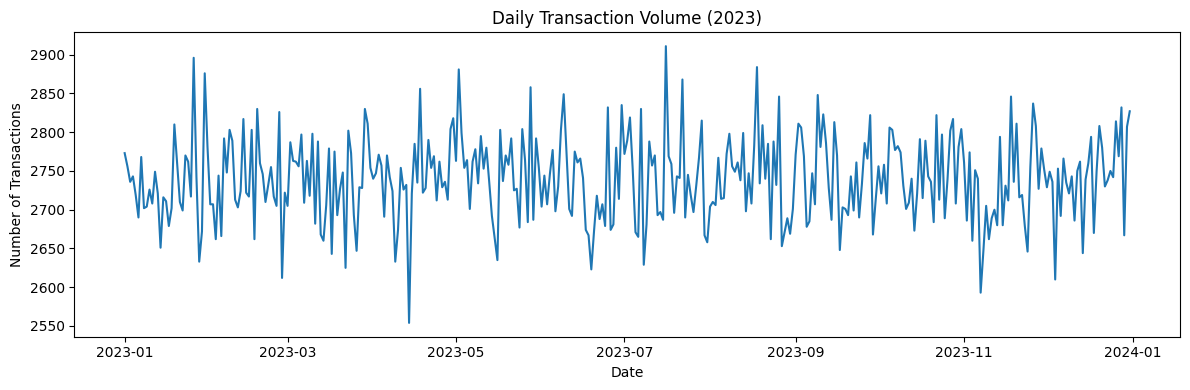

In [7]:
# Aggregate transaction counts by date
daily_transactions = (
    transactions
    .groupby(
        transactions["transaction_timestamp"].dt.date
    )
    .size()
    .rename("transaction_count")
)

display(daily_transactions.describe())

# Visualise daily transaction activity
fig, ax = plt.subplots(figsize=(12, 4))

daily_transactions.plot(ax=ax)

ax.set(
    title="Daily Transaction Volume (2023)",
    xlabel="Date",
    ylabel="Number of Transactions"
)

plt.tight_layout()
plt.show()

### 2.4.1 Data Quality Findings

The data quality assessment identified no missing values or duplicate records in either the customer or transaction dataset. All customer identifiers in the customer table and transaction identifiers in the transaction table were unique.

The recorded year and month fields were consistent with the transaction timestamps, indicating no discrepancies in the calendar attributes.

However, nine transaction records referenced customer identifiers that were absent from the customer table, representing approximately 0.0009% of all transactions.

These records will be excluded from subsequent analysis to ensure that customer activity is calculated using the registered customer population. The original datasets will remain unchanged, and the exclusion will be applied to a separate analytical dataset.

### 2.4.2 Initial Transaction Activity Assessment

The dataset contains transaction records for all 365 days of 2023, with an average of approximately 2,740 transactions per day.

Daily transaction volume remained relatively stable throughout the year, with a minimum of 2,554 and a maximum of 2,911 transactions.

The time-series visualisation does not reveal an obvious sustained trend or major structural change in transaction volume.

As the dataset is synthetic, these patterns may reflect the underlying data-generation process rather than real-world banking activity. Further analysis of unique active customers is required to determine whether the dataset contains meaningful temporal patterns for forecasting.


### 2.5 Data Cleaning

Transaction records containing customer identifiers that do not exist in the customer table are excluded from the analytical dataset.

This ensures that subsequent customer activity measures are calculated using valid customer references.

The original transaction dataset is preserved, while a separate cleaned DataFrame is created for further analysis and modelling.


In [8]:
# Retain transactions belonging to registered customers
transactions_clean = transactions.loc[
    transactions["customer_id"].isin(customers["customer_id"])
].copy()

print(f"Original transactions: {len(transactions):,}")
print(f"Cleaned transactions: {len(transactions_clean):,}")
print(f"Records removed: {len(transactions) - len(transactions_clean):,}")

Original transactions: 1,000,000
Cleaned transactions: 999,991
Records removed: 9


### 2.6 Daily Active Customer Aggregation

The transaction-level dataset is aggregated into a daily time series to establish the forecasting target.

Daily Active Customers (DAC) is defined as the number of unique registered customers who perform at least one recorded transaction within a calendar day.

Each customer is counted only once per day, regardless of the number of transactions performed.

The resulting daily activity series represents transaction-based customer engagement and serves as the primary target variable for the forecasting model.

Transaction counts are also retained as a supplementary activity measure to support exploratory analysis and potential feature engineering.


In [9]:
# Extract the calendar date from each transaction
transactions_clean["date"] = (
    transactions_clean["transaction_timestamp"].dt.date
)

# Aggregate customer activity and transaction volume
daily_activity = (
    transactions_clean
    .groupby("date")
    .agg(
        active_customers=("customer_id", "nunique"),
        transaction_count=("transaction_id", "count")
    )
    .reset_index()
)

# Convert the date column to datetime and use it as the index
daily_activity["date"] = pd.to_datetime(daily_activity["date"])

daily_activity = daily_activity.set_index("date").sort_index()

display(daily_activity.head())

print(f"Total days: {len(daily_activity)}")
print(f"Date range: {daily_activity.index.min()} to {daily_activity.index.max()}")

,active_customers,transaction_count
date,,
2023-01-01,2699,2772
2023-01-02,2688,2756
2023-01-03,2668,2736
2023-01-04,2670,2743
2023-01-05,2656,2719


Total days: 365
Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


In [10]:
# Confirm that all cleaned transactions are represented
assert daily_activity["transaction_count"].sum() == len(transactions_clean)

# Confirm that active customers cannot exceed transaction counts
assert (
    daily_activity["active_customers"]
    <= daily_activity["transaction_count"]
).all()

# Confirm that the time series contains every calendar day
expected_dates = pd.date_range(
    start=daily_activity.index.min(),
    end=daily_activity.index.max(),
    freq="D"
)

missing_dates = expected_dates.difference(daily_activity.index)

print(f"Missing dates: {len(missing_dates)}")
print(f"Total observations: {len(daily_activity)}")

display(daily_activity.describe())

Missing dates: 0
Total observations: 365


,active_customers,transaction_count
count,365.00,365.00
mean,"2,678.33","2,739.70"
std,52.47,54.52
min,"2,492.00","2,554.00"
25%,"2,644.00","2,703.00"
50%,"2,677.00","2,740.00"
75%,"2,712.00","2,775.00"
max,"2,842.00","2,911.00"


### 2.6.1 Daily Activity Aggregation: Findings

The transaction-level data was successfully aggregated into a daily time series containing 365 observations, covering the full calendar year of 2023.

The aggregation validation confirmed that all cleaned transactions were retained, daily active customer counts did not exceed transaction counts, and no calendar dates were missing.

Daily active customer counts averaged approximately 2,678, with a minimum of 2,492 and a maximum of 2,842. The standard deviation of approximately 52 customers indicates relatively limited day-to-day variation in customer activity.

Average daily transaction volume was approximately 2,740, exceeding the average daily active customer count. This reflects the distinction between transaction volume and unique customer activity, as individual customers may perform multiple transactions within a single day.

The resulting daily time series will serve as the primary dataset for exploratory analysis and subsequent forecasting.

Given the synthetic nature of the data and the relatively stable activity levels, further investigation is required to determine whether meaningful temporal patterns exist and whether an XGBoost model can improve upon simple forecasting baselines.


## 3. Exploratory Data Analysis

### 3.1 Daily Active Customer Trends

The first stage of exploratory analysis examines how daily active customer volumes change throughout the observation period.

Visualising the daily activity series helps identify potential trends, unusual fluctuations, changes in activity levels and recurring patterns that may influence forecasting performance.

A seven-day rolling average is included to smooth short-term fluctuations and provide a clearer view of the underlying activity pattern. The rolling average is used for exploratory purposes and is not used as a forecasting feature at this stage.


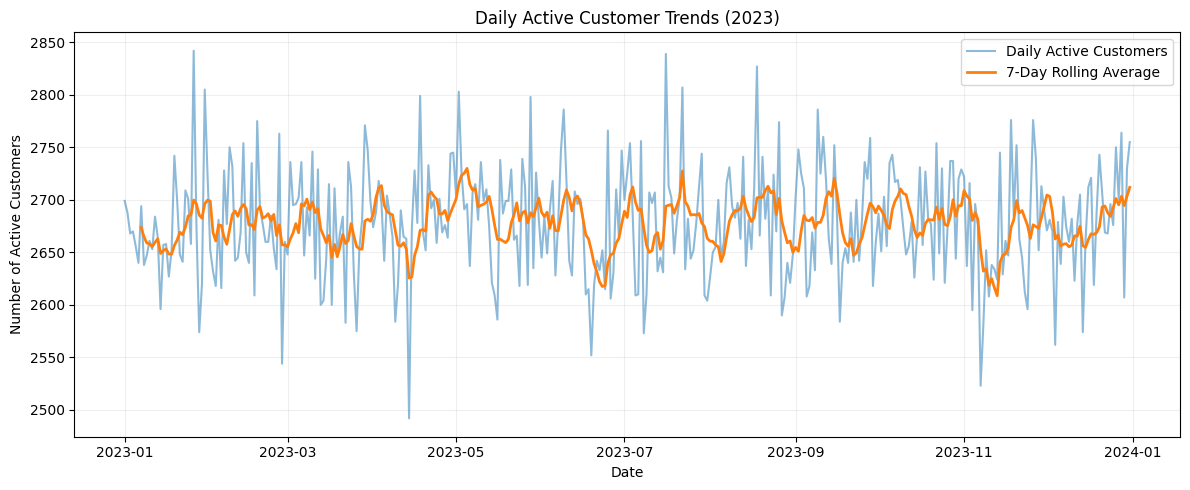

In [11]:
# Calculate the seven-day rolling average
daily_activity["dac_7d_avg"] = (
    daily_activity["active_customers"]
    .rolling(window=7, min_periods=7)
    .mean()
)

# Visualise daily active customers and the rolling average
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    daily_activity.index,
    daily_activity["active_customers"],
    label="Daily Active Customers",
    alpha=0.5
)

ax.plot(
    daily_activity.index,
    daily_activity["dac_7d_avg"],
    label="7-Day Rolling Average",
    linewidth=2
)

ax.set(
    title="Daily Active Customer Trends (2023)",
    xlabel="Date",
    ylabel="Number of Active Customers"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

#### 3.1.1 Daily Active Customer Trends: Findings

Daily active customer volumes fluctuate around an average of approximately 2,678 throughout 2023, with no clear sustained upward or downward trend.

The seven-day rolling average smooths short-term fluctuations but remains relatively stable across the observation period. Occasional peaks and troughs are visible, although these do not appear to represent prolonged changes in customer activity.

The absence of an obvious trend suggests that a simple forecasting approach based on historical activity levels may provide a useful benchmark.

Further investigation of temporal dependencies is required to determine whether historical observations contain sufficient predictive information for more complex forecasting models such as XGBoost.


### 3.2 Day-of-Week Activity Patterns

Customer activity may vary across different days of the week due to differences in transaction behaviour and banking usage patterns.

To investigate potential weekly seasonality, daily active customer counts are grouped by day of the week.

The analysis compares average customer activity across all seven days to determine whether recurring weekly patterns are present and whether day-of-week information may be useful for forecasting.


,mean,std,count
day_of_week,,,
Monday,"2,672.88",56.46,52
Tuesday,"2,678.48",49.86,52
Wednesday,"2,668.48",43.27,52
Thursday,"2,687.21",47.17,52
Friday,"2,679.60",55.16,52
Saturday,"2,677.13",55.13,52
Sunday,"2,684.40",58.95,53


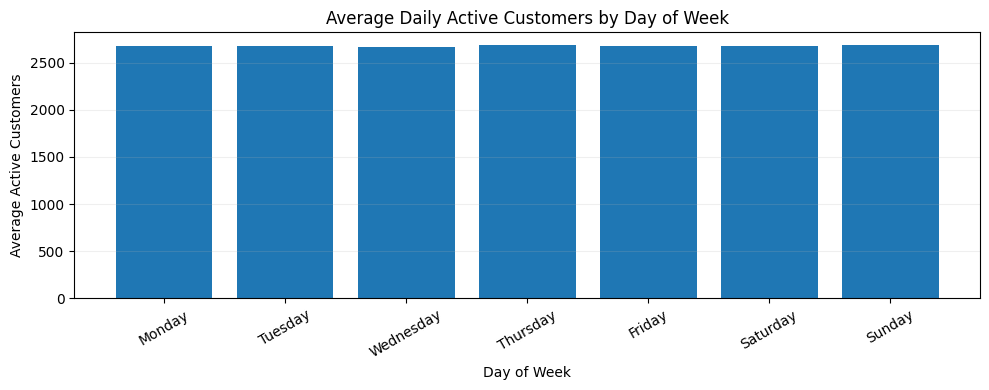

In [12]:
# Create day-of-week labels.
daily_activity["day_of_week"] = daily_activity.index.day_name()

day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

# Calculate average active customers by day of the week
weekday_activity = (
    daily_activity
    .groupby("day_of_week")["active_customers"]
    .agg(["mean", "std", "count"])
    .reindex(day_order)
)

display(weekday_activity.round(2))

# Visualise average customer activity by weekday
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    weekday_activity.index,
    weekday_activity["mean"]
)

ax.set(
    title="Average Daily Active Customers by Day of Week",
    xlabel="Day of Week",
    ylabel="Average Active Customers"
)

ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

#### 3.2.1 Day-of-Week Activity: Findings

Average daily active customer volumes remain relatively consistent across all seven days of the week.

Thursday records the highest average activity at approximately 2,687 customers, while Wednesday records the lowest at approximately 2,668 customers. The difference of approximately 19 customers represents less than 1% of the overall daily average.

No clear distinction is observed between weekday and weekend activity, and the differences between weekday averages are small relative to the variation observed within individual weekdays.

These findings provide limited evidence of a strong weekly seasonal pattern in the dataset.

Day-of-week information may still be considered during feature engineering, although its predictive contribution will need to be assessed through out-of-sample model evaluation rather than assumed from the descriptive analysis.


### 3.3 Monthly Customer Activity Patterns

Daily active customer counts are grouped by calendar month to examine broader changes in customer activity throughout 2023.

The analysis compares average daily active customer volumes across months, allowing for differences in the number of days per month.

This assessment aims to identify potential changes in activity levels that may not be immediately apparent in the daily time series.

As the dataset covers only one calendar year, any observed monthly differences cannot be interpreted as evidence of recurring annual seasonality.


,mean,std,min,max
date,,,,
2023-01-01,"2,673.90",53.26,2574,2842
2023-02-01,"2,672.64",53.35,2544,2775
2023-03-01,"2,676.84",52.76,2575,2771
2023-04-01,"2,679.00",53.57,2492,2799
2023-05-01,"2,690.52",50.88,2586,2803
2023-06-01,"2,668.77",53.94,2552,2786
2023-07-01,"2,680.42",61.16,2573,2839
2023-08-01,"2,679.13",51.74,2590,2827
2023-09-01,"2,683.43",52.28,2584,2786


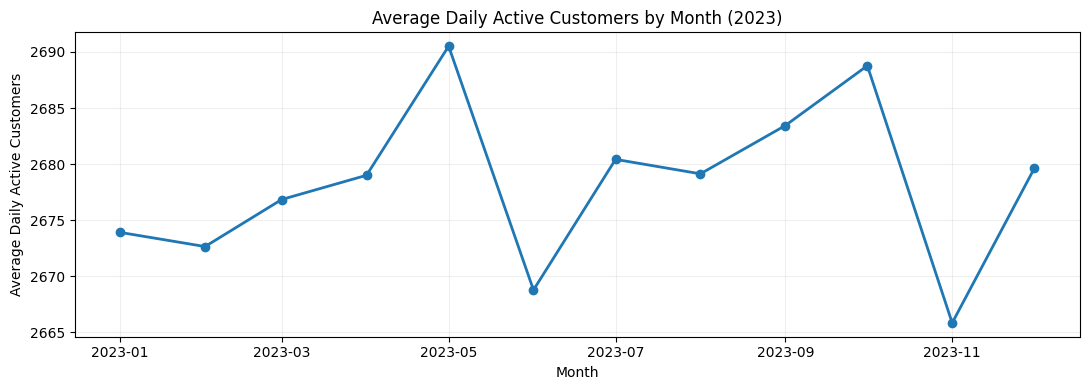

In [13]:
# Aggregate daily active customer counts by month
monthly_activity = (
    daily_activity["active_customers"]
    .resample("MS")
    .agg(["mean", "std", "min", "max"])
)

display(monthly_activity.round(2))

# Visualise average daily active customers by month
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    monthly_activity.index,
    monthly_activity["mean"],
    marker="o",
    linewidth=2
)

ax.set(
    title="Average Daily Active Customers by Month (2023)",
    xlabel="Month",
    ylabel="Average Daily Active Customers"
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

#### 3.3.1 Monthly Customer Activity: Findings

Average daily active customer volumes remain relatively stable across the twelve months of 2023.

May records the highest monthly average at approximately 2,691 active customers per day, while November records the lowest at approximately 2,666. The difference of approximately 25 customers represents less than 1% of the overall daily average.

Although the monthly visualisation shows some fluctuations, there is no clear sustained increase or decrease in customer activity throughout the year.

The relatively small differences between monthly averages provide limited evidence of a strong calendar-month effect.

Furthermore, as the dataset covers only one calendar year, recurring annual seasonality cannot be established.

These findings suggest that monthly calendar features may offer limited predictive value, although their usefulness would need to be assessed through out-of-sample evaluation.


### 3.4 Temporal Dependencies and Autocorrelation

Autocorrelation measures the relationship between a time series and its previous observations at different time lags.

Examining autocorrelation can help determine whether historical customer activity contains information that may be useful for predicting future activity.

The analysis considers lags of up to 30 days to investigate short-term temporal relationships and potential recurring patterns.

The findings will inform the selection of candidate lagged features for the forecasting model. However, the predictive usefulness of these features must ultimately be established through chronological out-of-sample evaluation.


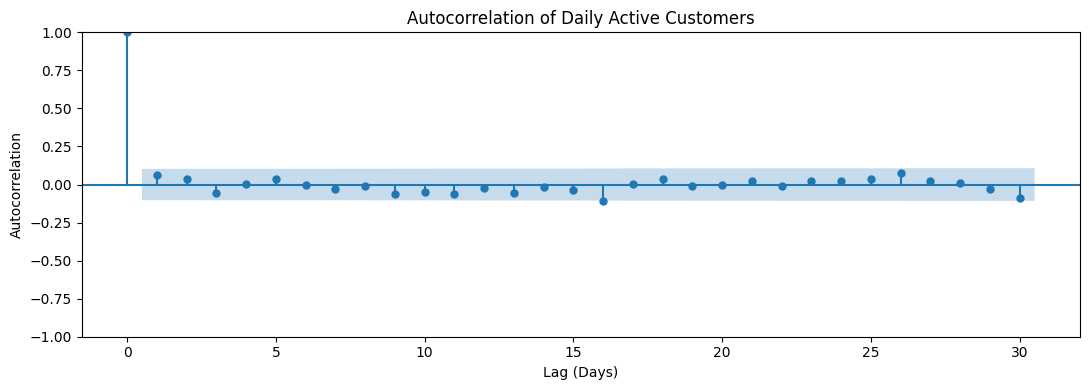

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(11, 4))

plot_acf(
    daily_activity["active_customers"],
    lags=30,
    alpha=0.05,
    ax=ax
)

ax.set(
    title="Autocorrelation of Daily Active Customers",
    xlabel="Lag (Days)",
    ylabel="Autocorrelation"
)

plt.tight_layout()
plt.show()

#### 3.4.1 Autocorrelation: Findings

The autocorrelation analysis reveals generally weak correlations between daily active customer counts and their historical observations across lags of 1–30 days.

All non-zero lag autocorrelations appear to remain within the approximate 95% confidence bounds, providing limited evidence of statistically significant linear temporal dependence at the examined lags.

In particular, no pronounced autocorrelation is observed at lag 1 or at weekly intervals such as lags 7 and 14.

These findings suggest that previous daily customer counts may provide limited predictive information for future activity.

However, weak autocorrelation does not rule out nonlinear relationships or interactions between historical and calendar-based features. The predictive usefulness of these features would need to be assessed through out-of-sample forecasting experiments.

Given the synthetic nature of the dataset, the observed lack of temporal structure may reflect the underlying data-generation process rather than genuine banking customer behaviour.


## 4. Forecasting Framework and Baseline Models

### 4.1 Forecasting Objective and Evaluation Strategy

The forecasting task is defined as predicting the number of unique customers expected to perform at least one transaction on the following day.

The analysis adopts a one-day-ahead forecasting framework, assuming that complete transaction activity for the previous day is available at the time of prediction.

To preserve the temporal ordering of observations, the dataset is divided chronologically into training, validation and test periods.

* Training: January-August 2023.
* Validation: September–October 2023.
* Testing: November–December 2023.

The training period is used to develop forecasting models, while the validation period supports model selection and hyperparameter tuning. The test period is reserved for the final evaluation of the selected forecasting approach.

Simple forecasting baselines are established before developing XGBoost to determine whether a more complex machine learning model provides additional predictive value.


In [15]:
# Retain only the variables required for forecasting
forecast_data = daily_activity[
    ["active_customers", "transaction_count"]
].copy()

# Define chronological split boundaries
TRAIN_END = "2023-08-31"
VAL_END = "2023-10-31"

train = forecast_data.loc[:TRAIN_END].copy()

val = forecast_data.loc[
    "2023-09-01":VAL_END
].copy()

test = forecast_data.loc[
    "2023-11-01":
].copy()

# Inspect the chronological splits
for name, data in [
    ("Training", train),
    ("Validation", val),
    ("Test", test)
]:
    print(
        f"{name}: {len(data)} observations | "
        f"{data.index.min().date()} to "
        f"{data.index.max().date()}"
    )

Training: 243 observations | 2023-01-01 to 2023-08-31
Validation: 61 observations | 2023-09-01 to 2023-10-31
Test: 61 observations | 2023-11-01 to 2023-12-31


### 4.2 Baseline Forecasting Models

Three baseline forecasting approaches are implemented to establish reference performance before developing the XGBoost model.

The naive forecast uses the previous day's observed customer count as the prediction for the following day.

The seven-day moving average uses the mean customer activity over the preceding seven days, reducing the influence of individual daily fluctuations.

The historical expanding mean uses the average of all observations available before the forecast date. This approach is particularly relevant given the relatively stable activity levels observed during exploratory analysis.

All baseline predictions are generated using historical observations only, preventing future information from entering the forecasts.

Baseline performance will be assessed on the validation period using MAE, RMSE and MAPE.


In [16]:
def create_baseline_forecasts(series):
    """Generate one-day-ahead forecasts using historical observations."""

    return pd.DataFrame({
        "naive": series.shift(1),

        "moving_average_7d": (
            series.shift(1)
            .rolling(window=7, min_periods=7)
            .mean()
        ),

        "expanding_mean": (
            series.shift(1)
            .expanding(min_periods=7)
            .mean()
        )
    })


# Generate forecasts using the complete historical series
baseline_forecasts = create_baseline_forecasts(
    forecast_data["active_customers"]
)

# Extract validation predictions
baseline_val = baseline_forecasts.loc[val.index]

display(baseline_val.head())

,naive,moving_average_7d,expanding_mean
date,,,
2023-09-01,"2,648.00","2,650.00","2,677.74"
2023-09-02,"2,703.00","2,654.71","2,677.85"
2023-09-03,"2,748.00","2,651.00","2,678.13"
2023-09-04,"2,725.00","2,670.29","2,678.33"
2023-09-05,"2,711.00","2,685.14","2,678.46"


### 4.3 Forecast Evaluation Metrics

Forecasting performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and Mean Absolute Percentage Error (MAPE).

MAE measures the average absolute deviation between actual and predicted customer counts, providing an interpretable measure of forecasting error in customer units.

RMSE places greater emphasis on larger prediction errors, making it useful for identifying models that produce occasional substantial deviations.

MAPE expresses the average absolute forecasting error as a percentage of actual customer activity, allowing performance to be interpreted relative to the observed customer volumes.

MAE is used as the primary model-selection metric, while RMSE and MAPE provide supplementary measures of forecasting performance.


In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)


def evaluate_forecast(y_true, y_pred):
    """Calculate forecasting error metrics."""

    return {
        "MAE": mean_absolute_error(y_true, y_pred),

        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),

        "MAPE (%)": (
            mean_absolute_percentage_error(y_true, y_pred) * 100
        )
    }


# Evaluate baseline models on the validation period
baseline_results = pd.DataFrame({
    model: evaluate_forecast(
        val["active_customers"],
        baseline_val[model]
    )
    for model in baseline_val.columns
}).T

display(baseline_results.round(3))

,MAE,RMSE,MAPE (%)
naive,51.13,61.68,1.91
moving_average_7d,44.99,52.44,1.67
expanding_mean,39.45,46.34,1.47


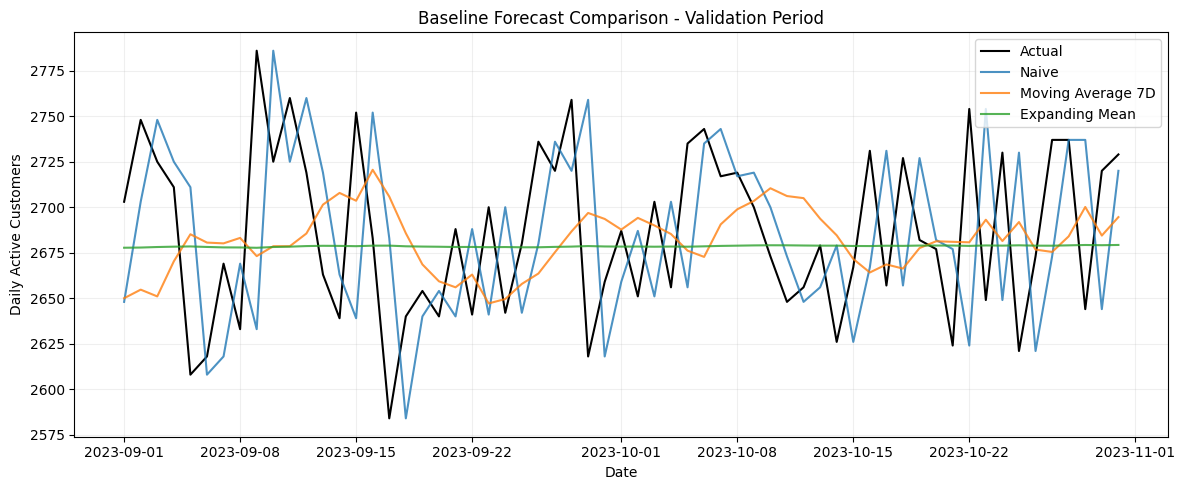

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    val.index,
    val["active_customers"],
    label="Actual",
    color="black",
    linewidth=1.5
)

for model in baseline_val.columns:
    ax.plot(
        baseline_val.index,
        baseline_val[model],
        label=model.replace("_", " ").title(),
        alpha=0.8
    )

ax.set(
    title="Baseline Forecast Comparison - Validation Period",
    xlabel="Date",
    ylabel="Daily Active Customers"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 4.4 Baseline Forecasting Results

Three baseline forecasting approaches were evaluated on the September–October 2023 validation period, comprising 61 daily observations.

The historical expanding mean achieved the lowest validation errors, with an MAE of 39.45 customers, RMSE of 46.34 customers and MAPE of 1.465%.

The seven-day moving average produced an MAE of 44.99 customers, while the naive forecast recorded the highest MAE at 51.13 customers.

The visual comparison shows that the naive forecast closely follows the previous day's activity but does not consistently anticipate subsequent fluctuations. The seven-day moving average produces smoother predictions, while the expanding mean remains close to the historical activity level.

These findings are consistent with the exploratory analysis, which identified relatively stable daily customer volumes and limited evidence of temporal dependence.

The expanding mean is therefore retained as the principal benchmark for assessing whether XGBoost can provide additional predictive value.

The test period remains reserved for final evaluation after model development and selection.


## 5. XGBoost Forecasting Model

### 5.1 Feature Engineering

XGBoost is a supervised machine learning algorithm that requires a structured feature matrix to learn relationships between explanatory variables and the forecasting target.

To adapt the daily customer activity series for supervised learning, historical activity and calendar-based features are constructed.

The feature set includes:

* Lagged active customer counts at 1, 2, 3, 7 and 14 days.
* Seven-day and 14-day rolling averages and standard deviations of historical customer activity.
* Lagged transaction volumes at 1 and 7 days.
* Day-of-week and month indicators.

Lagged and rolling features are constructed using observations available before the forecast date to prevent data leakage.

The initial feature set is intentionally limited to interpretable variables relevant to the forecasting objective. Its predictive usefulness will be assessed through chronological validation rather than assumed from exploratory analysis.


In [19]:
def create_forecasting_features(df):
    """Create leakage-safe features for one-day-ahead forecasting."""

    features = df.copy()

    # Historical customer activity
    for lag in [1, 2, 3, 7, 14]:
        features[f"dac_lag_{lag}"] = (
            features["active_customers"].shift(lag)
        )

    # Historical rolling statistics
    historical_dac = features["active_customers"].shift(1)

    for window in [7, 14]:
        features[f"dac_rolling_mean_{window}"] = (
            historical_dac.rolling(window).mean()
        )

        features[f"dac_rolling_std_{window}"] = (
            historical_dac.rolling(window).std()
        )

    # Historical transaction volume
    for lag in [1, 7]:
        features[f"transactions_lag_{lag}"] = (
            features["transaction_count"].shift(lag)
        )

    # Calendar features
    features["day_of_week"] = features.index.dayofweek
    features["month"] = features.index.month

    return features.dropna()


# Construct features using the complete chronological series
model_data = create_forecasting_features(forecast_data)

display(model_data.head())

print(f"Modelling observations: {len(model_data)}")
print(f"Total columns: {model_data.shape[1]}")

,active_customers,transaction_count,dac_lag_1,dac_lag_2,dac_lag_3,dac_lag_7,dac_lag_14,dac_rolling_mean_7,dac_rolling_std_7,dac_rolling_mean_14,dac_rolling_std_14,transactions_lag_1,transactions_lag_7,day_of_week,month
date,,,,,,,,,,,,,,,
2023-01-15,2657,2716,"2,596.00","2,664.00","2,684.00","2,638.00","2,699.00","2,649.00",27.52,"2,661.29",26.90,"2,651.00","2,702.00",6,1
2023-01-16,2658,2711,"2,657.00","2,596.00","2,664.00","2,647.00","2,688.00","2,651.71",27.19,"2,658.29",24.62,"2,716.00","2,704.00",0,1
2023-01-17,2627,2679,"2,658.00","2,657.00","2,596.00","2,661.00","2,668.00","2,653.29",27.19,"2,656.14",23.09,"2,711.00","2,726.00",1,1
2023-01-18,2652,2702,"2,627.00","2,658.00","2,657.00","2,653.00","2,670.00","2,648.43",28.58,"2,653.21",24.05,"2,679.00","2,708.00",2,1
2023-01-19,2742,2810,"2,652.00","2,627.00","2,658.00","2,684.00","2,656.00","2,648.29",28.56,"2,651.93",23.56,"2,702.00","2,749.00",3,1


Modelling observations: 351
Total columns: 15


In [20]:
TARGET = "active_customers"

# Exclude the target and current-day transaction volume
FEATURES = [
    col for col in model_data.columns
    if col not in [TARGET, "transaction_count"]
]

# Apply the existing chronological boundaries
train_ml = model_data.loc[:TRAIN_END]
val_ml = model_data.loc["2023-09-01":VAL_END]
test_ml = model_data.loc["2023-11-01":]

# Separate predictors and target.
X_train = train_ml[FEATURES]
y_train = train_ml[TARGET]

X_val = val_ml[FEATURES]
y_val = val_ml[TARGET]

X_test = test_ml[FEATURES]
y_test = test_ml[TARGET]

print(f"Training: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

print("\nFeatures:")
print(FEATURES)

# Validate chronological ordering and feature completeness
assert X_train.index.max() < X_val.index.min()
assert X_val.index.max() < X_test.index.min()

assert not X_train.isna().any().any()
assert not X_val.isna().any().any()
assert not X_test.isna().any().any()

Training: (229, 13)
Validation: (61, 13)
Test: (61, 13)

Features:
['dac_lag_1', 'dac_lag_2', 'dac_lag_3', 'dac_lag_7', 'dac_lag_14', 'dac_rolling_mean_7', 'dac_rolling_std_7', 'dac_rolling_mean_14', 'dac_rolling_std_14', 'transactions_lag_1', 'transactions_lag_7', 'day_of_week', 'month']


### 5.2 Initial XGBoost Model

An initial XGBoost regression model is trained using the engineered historical activity and calendar-based features.

Given the relatively small number of training observations and the limited temporal structure identified during EDA, the initial model uses shallow decision trees and regularisation to reduce the risk of overfitting.

The model is evaluated on the validation period using the same forecasting metrics applied to the baseline models.

The purpose of this initial experiment is to establish whether XGBoost can identify predictive relationships that improve upon the historical expanding-mean benchmark before undertaking further model refinement.


In [21]:
from xgboost import XGBRegressor

# Initialise the model
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    max_depth=2,
    learning_rate=0.03,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train using historical observations only
xgb_model.fit(X_train, y_train)

# Generate one-day-ahead validation predictions
xgb_val_pred = xgb_model.predict(X_val)

# Compare XGBoost against the existing baselines
xgb_results = pd.DataFrame(
    [evaluate_forecast(y_val, xgb_val_pred)],
    index=["XGBoost"]
)

validation_results = pd.concat([
    baseline_results,
    xgb_results
])

display(validation_results.round(3))

,MAE,RMSE,MAPE (%)
naive,51.13,61.68,1.91
moving_average_7d,44.99,52.44,1.67
expanding_mean,39.45,46.34,1.47
XGBoost,39.20,45.32,1.46


### 5.2.1 Initial XGBoost Model: Validation Results

The initial XGBoost regression model was trained using 229 daily observations and 13 engineered features, including lagged customer activity, historical rolling statistics, lagged transaction volumes and calendar variables.

The model was evaluated on the September–October 2023 validation period, comprising 61 one-day-ahead forecasts.

XGBoost achieved an MAE of 39.197 customers, RMSE of 45.320 customers and MAPE of 1.457%.

Compared with the historical expanding-mean baseline, which achieved an MAE of 39.451 customers, XGBoost reduced the average absolute forecasting error by approximately 0.25 customers, representing an improvement of 0.64%.

Although XGBoost achieved slightly lower validation errors, the improvement was marginal. The results do not establish whether the model has learned meaningful predictive relationships or whether the difference reflects variation within the validation period.

Further analysis of model predictions, training performance and feature importance is required before considering hyperparameter optimisation.

The test period remains reserved for final evaluation of the selected forecasting approach.


### 5.3 Training and Validation Performance

Training and validation errors are compared to investigate whether the initial XGBoost model generalises beyond the observations used during model fitting.

A substantially lower training error relative to validation error may indicate overfitting, particularly when the model is trained on a relatively small dataset.

The comparison is used as an initial diagnostic alongside visual inspection of predictions and feature importance.

Model development decisions will continue to be based on chronological validation performance rather than training accuracy alone.


In [22]:
# Generate predictions for the training period
xgb_train_pred = xgb_model.predict(X_train)

# Evaluate training and validation performance
xgb_performance = pd.DataFrame({
    "Training": evaluate_forecast(y_train, xgb_train_pred),
    "Validation": evaluate_forecast(y_val, xgb_val_pred)
}).T

display(xgb_performance.round(3))

,MAE,RMSE,MAPE (%)
Training,33.99,43.96,1.27
Validation,39.20,45.32,1.46


#### 5.3.1 Training and Validation Performance: Findings

The initial XGBoost model achieved a training MAE of 33.99 customers and a validation MAE of 39.20 customers.

The corresponding RMSE values were 43.96 and 45.32 customers, while MAPE increased from 1.27% during training to 1.46% during validation.

The higher validation errors indicate some deterioration in performance on unseen observations, although the difference does not provide clear evidence of severe overfitting.

Despite achieving slightly lower validation errors than the expanding-mean baseline, the improvement remains marginal.

These findings suggest that further model development should focus on generalisation and whether the engineered features provide meaningful predictive value, rather than increasing model complexity.


### 5.4 Actual Versus Predicted Customer Activity

The initial XGBoost forecasts are compared with observed daily active customer counts and the historical expanding-mean baseline over the validation period.

This visualisation is used to assess how the model responds to fluctuations in customer activity and whether it produces meaningfully different predictions from the simpler forecasting approach.

The comparison complements the quantitative evaluation metrics by highlighting potential systematic errors, excessive prediction variability or a tendency to forecast values close to the historical average.


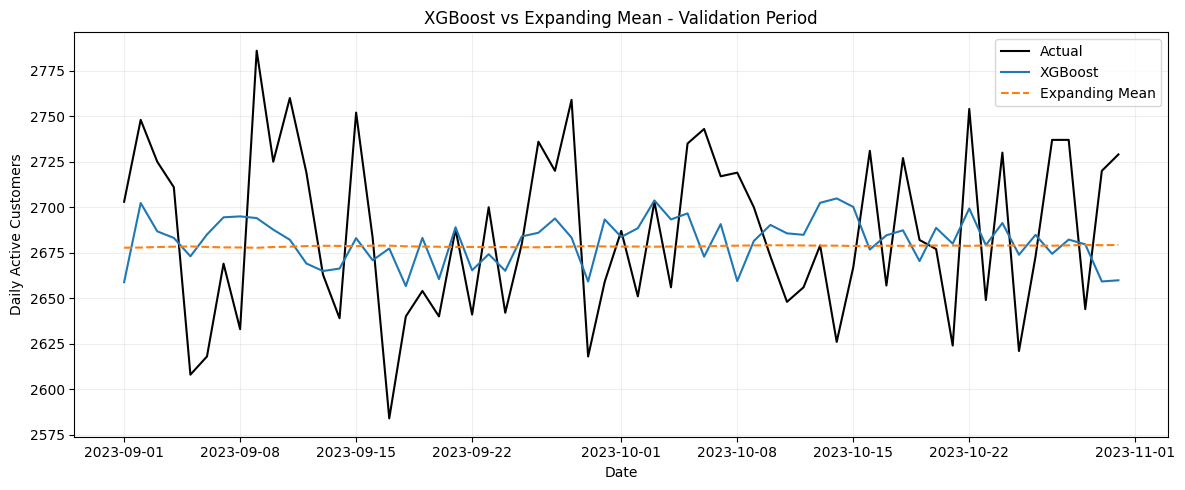

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    y_val.index,
    y_val,
    label="Actual",
    color="black",
    linewidth=1.5
)

ax.plot(
    y_val.index,
    xgb_val_pred,
    label="XGBoost",
    linewidth=1.5
)

ax.plot(
    y_val.index,
    baseline_val["expanding_mean"],
    label="Expanding Mean",
    linestyle="--",
    linewidth=1.5
)

ax.set(
    title="XGBoost vs Expanding Mean - Validation Period",
    xlabel="Date",
    ylabel="Daily Active Customers"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

#### 5.4.1 Actual Versus Predicted Activity: Findings

The validation forecast comparison shows that both XGBoost and the historical expanding mean produce predictions close to the overall customer activity level.

The expanding-mean baseline remains relatively constant throughout the validation period, while XGBoost generates more variable predictions in response to the engineered features.

However, neither approach consistently anticipates the larger daily peaks and troughs observed in actual customer activity.

Although XGBoost produces slightly lower validation errors, its predictions do not demonstrate a substantial improvement over the expanding mean.

This behaviour is consistent with the exploratory analysis, which identified relatively stable customer activity and weak historical autocorrelation.

The findings suggest that much of the daily variation may be difficult to predict using the available historical activity and calendar-based features.


### 5.5 Feature Importance Analysis

Feature importance is examined to understand which engineered variables contribute most strongly to the fitted XGBoost model.

The analysis considers historical customer activity, rolling statistics, lagged transaction volumes and calendar-based features.

Feature importance scores provide insight into the model's internal prediction process but do not establish causal relationships or guarantee that the identified features improve forecasting accuracy on unseen data.

The results will be interpreted alongside validation performance and the temporal patterns identified during exploratory analysis.


,Importance
dac_lag_14,0.09
dac_lag_2,0.09
dac_lag_3,0.08
dac_lag_1,0.08
dac_rolling_mean_7,0.08
dac_rolling_std_7,0.08
dac_rolling_mean_14,0.08
transactions_lag_1,0.08
dac_rolling_std_14,0.08
transactions_lag_7,0.07


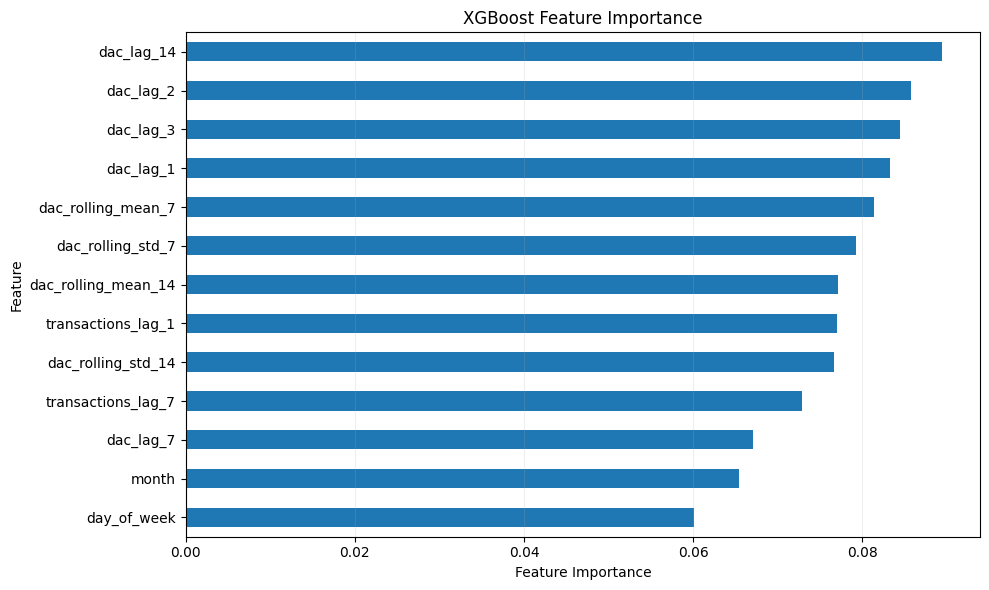

In [24]:
# Extract feature importance scores
feature_importance = (
    pd.Series(
        xgb_model.feature_importances_,
        index=FEATURES,
        name="Importance"
    )
    .sort_values(ascending=False)
)

display(feature_importance.to_frame().round(4))

# Visualise feature importance
fig, ax = plt.subplots(figsize=(10, 6))

feature_importance.sort_values().plot.barh(ax=ax)

ax.set(
    title="XGBoost Feature Importance",
    xlabel="Feature Importance",
    ylabel="Feature"
)

ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

#### 5.5.1 Feature Importance: Findings

The initial XGBoost feature importance analysis identifies the 14-day customer activity lag as the highest-ranked feature, followed by the two-day and three-day lags.

Historical rolling statistics and lagged transaction volumes also contribute to the fitted model, while day-of-week information receives the lowest importance score.

The importance scores are relatively evenly distributed across the feature set, with no single variable overwhelmingly dominating the model.

Although historical customer activity features receive relatively high importance scores, these findings should be interpreted cautiously.

The earlier autocorrelation analysis identified limited evidence of temporal dependence, and the model's improvement over the expanding-mean baseline was marginal.

Feature importance reflects how the fitted model uses the available variables but does not establish that these relationships are stable or provide meaningful predictive value on unseen data.

A simplified feature set will therefore be evaluated to investigate whether reducing model complexity improves generalisation.


### 5.6 Feature Selection Experiment

A simplified feature set is evaluated to investigate whether reducing the number of predictors improves the generalisation of the XGBoost model.

The initial model contains 13 engineered features, several of which represent overlapping aspects of historical customer activity.

Given the relatively small training dataset and limited temporal structure identified during exploratory analysis, a reduced feature set may help limit unnecessary model complexity.

The simplified model retains recent customer activity, a seven-day historical rolling average, lagged transaction volume and day-of-week information.

The XGBoost hyperparameters and chronological validation period are kept unchanged to allow a controlled comparison with the initial model.

The experiment assesses whether a smaller feature set can achieve comparable or improved validation accuracy without introducing additional model complexity.


In [25]:
# Define a simplified feature set
SIMPLE_FEATURES = [
    "dac_lag_1",
    "dac_lag_7",
    "dac_rolling_mean_7",
    "transactions_lag_1",
    "day_of_week"
]

# Select the same features across chronological splits
X_train_simple = X_train[SIMPLE_FEATURES]
X_val_simple = X_val[SIMPLE_FEATURES]

# Reuse the initial model configuration
simple_xgb = XGBRegressor(
    **xgb_model.get_params()
)

# Train the simplified model
simple_xgb.fit(X_train_simple, y_train)

# Generate validation predictions
simple_val_pred = simple_xgb.predict(X_val_simple)

# Evaluate the simplified model
simple_results = pd.DataFrame(
    [evaluate_forecast(y_val, simple_val_pred)],
    index=["XGBoost (Simplified)"]
)

# Compare against the original model and expanding-mean baseline
feature_comparison = pd.concat([
    baseline_results.loc[["expanding_mean"]],
    xgb_results,
    simple_results
])

display(feature_comparison.round(3))

,MAE,RMSE,MAPE (%)
expanding_mean,39.45,46.34,1.47
XGBoost,39.20,45.32,1.46
XGBoost (Simplified),39.66,45.23,1.47


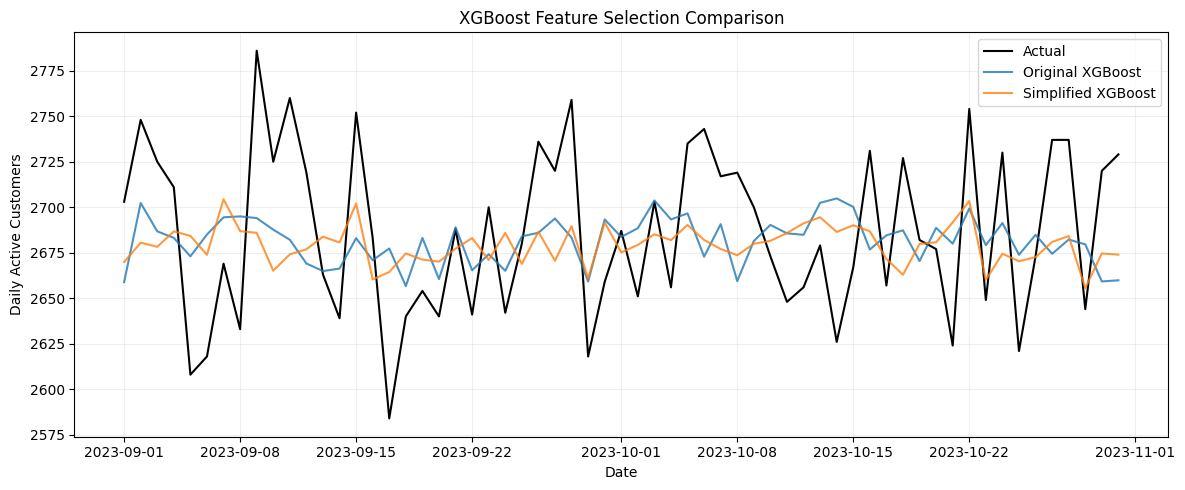

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    y_val.index,
    y_val,
    label="Actual",
    color="black",
    linewidth=1.5
)

ax.plot(
    y_val.index,
    xgb_val_pred,
    label="Original XGBoost",
    alpha=0.8
)

ax.plot(
    y_val.index,
    simple_val_pred,
    label="Simplified XGBoost",
    alpha=0.8
)

ax.set(
    title="XGBoost Feature Selection Comparison",
    xlabel="Date",
    ylabel="Daily Active Customers"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

#### 5.6.1 Feature Selection Results

The simplified XGBoost model was evaluated using five predictors, compared with the original model's 13 engineered features.

Both models were trained using the same chronological training period and hyperparameter configuration, allowing the effect of feature reduction to be assessed independently.

The original XGBoost model achieved a validation MAE of 39.20 customers, RMSE of 45.32 customers and MAPE of 1.46%.

The simplified model achieved an MAE of 39.66 customers, RMSE of 45.23 customers and MAPE of 1.47%.

Although the simplified model produced a slightly lower RMSE, the original model achieved a lower MAE, which was established as the primary model-selection metric.

The visual comparison shows that both models produce forecasts close to the historical average customer activity level, without consistently anticipating larger daily fluctuations.

Overall, reducing the feature set did not produce a substantial improvement in validation accuracy.

The original 13-feature configuration is therefore retained for the next modelling experiment, while recognising that its advantage over the simplified model is marginal and may not generalise to future observations.


### 5.7 Hyperparameter Tuning

A limited hyperparameter search is conducted to investigate whether adjustments to model complexity and regularisation improve the generalisation of the XGBoost forecasting model.

The experiment retains the original 13-feature configuration and evaluates a small set of predefined hyperparameter combinations.

Time-series cross-validation is used within the training period to preserve chronological ordering and assess model performance across multiple validation windows.

The search focuses on tree depth, learning rate, number of estimators and regularisation.

Mean Absolute Error (MAE) is used as the primary optimisation metric, consistent with the baseline and initial XGBoost evaluations.

The external validation period remains available for assessing the selected configuration, while the November–December test period is reserved for final evaluation.


In [27]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import ParameterGrid

# Define a small set of candidate configurations
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [1, 2],
    "learning_rate": [0.03, 0.05],
    "reg_lambda": [10]
}

# Use expanding-window chronological cross-validation
tscv = TimeSeriesSplit(n_splits=3)

cv_results = []

for params in ParameterGrid(param_grid):

    fold_mae = []

    for train_idx, val_idx in tscv.split(X_train):

        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]

        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]

        model = XGBRegressor(
            objective="reg:squarederror",
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **params
        )

        model.fit(X_fold_train, y_fold_train)

        predictions = model.predict(X_fold_val)

        fold_mae.append(
            mean_absolute_error(y_fold_val, predictions)
        )

    cv_results.append({
        **params,
        "CV_MAE": np.mean(fold_mae),
        "CV_MAE_STD": np.std(fold_mae)
    })

cv_results = (
    pd.DataFrame(cv_results)
    .sort_values("CV_MAE")
    .reset_index(drop=True)
)

display(cv_results.round(3))

,learning_rate,max_depth,n_estimators,reg_lambda,CV_MAE,CV_MAE_STD
0,0.03,1,100,10,43.90,2.17
1,0.03,2,100,10,44.56,2.25
2,0.05,1,100,10,44.95,1.85
3,0.03,1,200,10,45.28,1.80
4,0.05,2,100,10,45.91,2.73
5,0.05,1,200,10,46.05,2.21
6,0.03,2,200,10,46.15,2.86
7,0.05,2,200,10,47.94,3.20


In [28]:
# Extract the configuration with the lowest CV MAE
best_params = {
    key: int(cv_results.loc[0, key])
    if key in ["n_estimators", "max_depth"]
    else float(cv_results.loc[0, key])
    for key in param_grid
}

print("Selected hyperparameters:")
print(best_params)

# Train the selected configuration
tuned_xgb = XGBRegressor(
    objective="reg:squarederror",
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params
)

tuned_xgb.fit(X_train, y_train)

# Evaluate on the external validation period
tuned_val_pred = tuned_xgb.predict(X_val)

tuned_results = pd.DataFrame(
    [evaluate_forecast(y_val, tuned_val_pred)],
    index=["XGBoost (Tuned)"]
)

# Compare all relevant forecasting approaches
model_comparison = pd.concat([
    baseline_results.loc[["expanding_mean"]],
    xgb_results,
    simple_results,
    tuned_results
])

display(model_comparison.round(3))

Selected hyperparameters:
{'n_estimators': 100, 'max_depth': 1, 'learning_rate': 0.03, 'reg_lambda': 10.0}


,MAE,RMSE,MAPE (%)
expanding_mean,39.45,46.34,1.47
XGBoost,39.20,45.32,1.46
XGBoost (Simplified),39.66,45.23,1.47
XGBoost (Tuned),38.88,45.06,1.44


#### 5.7.1 Hyperparameter Tuning Results

A limited hyperparameter search was conducted using three-fold time-series cross-validation within the training period.

Eight predefined XGBoost configurations were evaluated, varying the number of estimators, maximum tree depth and learning rate while maintaining a fixed L2 regularisation parameter.

The configuration with 100 estimators, a maximum tree depth of 1, a learning rate of 0.03 and an L2 regularisation parameter of 10 achieved the lowest average cross-validation MAE of 43.90 customers.

The selected configuration was subsequently trained on the full training period and evaluated on the September–October 2023 validation period.

The tuned model achieved an MAE of 38.88 customers, RMSE of 45.06 customers and MAPE of 1.44%.

Compared with the historical expanding-mean baseline, the tuned model reduced MAE by approximately 1.45%.

Although the tuned configuration achieved lower validation errors than the initial and simplified XGBoost models, the improvement remained relatively small.

The results suggest that a more conservative XGBoost configuration may be appropriate for the available dataset, although the generalisability of this finding requires evaluation on the independent test period.

The tuned configuration is selected for final testing, with no further hyperparameter adjustments planned.


## 6. Final Model Evaluation

### 6.1 Final Model Training and Test Strategy

Following hyperparameter tuning and validation, the selected XGBoost configuration is retrained using the combined training and validation periods, covering January–October 2023.

The final model retains the original 13 engineered features and the hyperparameters selected through time-series cross-validation.

The November–December 2023 test period is reserved for independent evaluation.

Forecasts are generated using a one-day-ahead forecasting framework, where actual customer activity from the preceding day is assumed to be available before each subsequent prediction.

The final XGBoost model is compared against the naive forecast, seven-day moving average and historical expanding mean.

Performance is evaluated using MAE, RMSE and MAPE, with MAE retained as the primary evaluation metric.

This comparison assesses whether the tuned XGBoost model provides additional predictive value over simpler forecasting approaches on observations not used during model development.

**Forecasting Protocol:** All predictions follow a one-day-ahead forecasting framework. Actual customer activity from the preceding day is assumed to be available before each new prediction. Baseline forecasts and XGBoost features therefore incorporate newly observed historical activity as the evaluation period progresses. XGBoost model parameters remain fixed throughout each evaluation period.


In [29]:
# Combine training and validation observations
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

# Initialise the final model using the selected configuration
final_xgb = XGBRegressor(
    objective="reg:squarederror",
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params
)

# Train using January–October observations
final_xgb.fit(X_train_final, y_train_final)

# Generate forecasts for the untouched test period
final_test_pred = final_xgb.predict(X_test)

print(f"Final training observations: {len(X_train_final)}")
print(f"Test observations: {len(X_test)}")

Final training observations: 290
Test observations: 61


In [30]:
# Extract baseline forecasts for the test period
baseline_test = baseline_forecasts.loc[y_test.index]

# Evaluate each baseline model.
test_results = pd.DataFrame({
    model: evaluate_forecast(
        y_test,
        baseline_test[model]
    )
    for model in baseline_test.columns
}).T

# Evaluate the final XGBoost model
test_results.loc["XGBoost (Final)"] = evaluate_forecast(
    y_test,
    final_test_pred
)

display(test_results.round(3))

,MAE,RMSE,MAPE (%)
naive,58.85,71.69,2.21
moving_average_7d,43.10,57.01,1.62
expanding_mean,42.45,54.30,1.59
XGBoost (Final),43.63,54.97,1.64


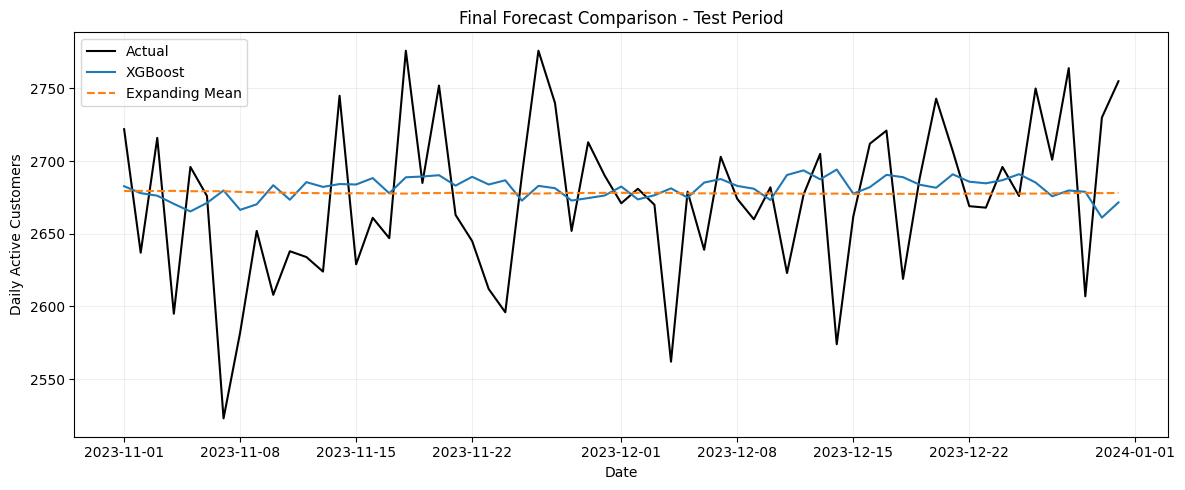

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    y_test.index,
    y_test,
    label="Actual",
    color="black",
    linewidth=1.5
)

ax.plot(
    y_test.index,
    final_test_pred,
    label="XGBoost",
    linewidth=1.5
)

ax.plot(
    y_test.index,
    baseline_test["expanding_mean"],
    label="Expanding Mean",
    linestyle="--",
    linewidth=1.5
)

ax.set(
    title="Final Forecast Comparison - Test Period",
    xlabel="Date",
    ylabel="Daily Active Customers"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 6.2 Final Test Results

The selected XGBoost model was retrained using the combined training and validation observations and evaluated on the independent November-December 2023 test period, comprising 61 daily observations.

The final XGBoost model achieved an MAE of 43.63 customers, RMSE of 54.97 customers and MAPE of 1.64%.

The historical expanding-mean baseline achieved an MAE of 42.45 customers, RMSE of 54.30 customers and MAPE of 1.59%, recording lower errors across all three evaluation metrics.

The seven-day moving average achieved an MAE of 43.10 customers, while the naive forecast produced the highest MAE at 58.85 customers.

Although XGBoost achieved a slightly lower MAE than the expanding mean during validation, this improvement did not persist on the independent test period.

The final XGBoost model recorded an MAE approximately 2.78% higher than the expanding-mean baseline.

The results indicate that the additional complexity of XGBoost did not provide a measurable forecasting advantage over the historical expanding mean on the test period.

These findings are consistent with the exploratory analysis, which identified relatively stable daily customer activity and limited evidence of temporal dependence.

The results should be interpreted within the context of the synthetic dataset and the specific evaluation period rather than generalised to real-world banking customer behaviour.


## 7. Conclusions and Limitations

### 7.1 Key Findings

This project investigated the use of XGBoost to forecast daily active banking customers using historical transaction activity.

The analysis was conducted on a synthetic dataset containing approximately one million transactions across 60,000 customers during 2023.

Daily active customers were defined as the number of unique customers performing at least one transaction on a given day.

Exploratory analysis revealed relatively stable daily customer activity, limited weekday and monthly variation, and weak autocorrelation across the examined historical lags.

Three baseline forecasting approaches were established: the naive forecast, seven-day moving average and historical expanding mean.

An XGBoost regression model was subsequently developed using lagged customer activity, historical rolling statistics, lagged transaction volumes and calendar-based features.

The model was evaluated using chronological data splitting, feature selection experiments and time-series cross-validation for hyperparameter tuning.

Although the tuned XGBoost model achieved a marginal improvement over the expanding-mean baseline during validation, this improvement did not persist on the independent test period.

The final XGBoost model achieved a test MAE of 43.63 customers, compared with 42.45 customers for the expanding mean.

The results demonstrate that a more complex machine learning model does not necessarily provide greater forecasting accuracy when the available historical data contains limited predictive information.

For this dataset and evaluation period, the historical expanding mean provided a simpler forecasting approach with slightly lower test errors.

### 7.2 Limitations

**Synthetic data:** The dataset is synthetic and may not reflect realistic banking customer behaviour, transaction patterns or operational conditions.

**Limited historical coverage:** The dataset contains one calendar year of observations, restricting the ability to investigate recurring annual seasonality or longer-term changes in customer activity.

**Limited temporal dependence:** Exploratory analysis identified weak historical autocorrelation, potentially limiting the predictive value of lagged customer activity and rolling statistics.

**Restricted feature availability:** The model uses historical transaction activity and calendar variables but does not incorporate external factors such as holidays, marketing campaigns, service disruptions or broader economic conditions.

**Evaluation scope:** The final assessment is based on a single 61-day independent test period. Additional historical data and multiple evaluation windows would be required to assess performance stability across different conditions.

**Forecasting horizon:** The analysis focuses exclusively on one-day-ahead forecasting. The results do not establish model performance for longer forecasting horizons.

### 7.3 Future Work

Future development could investigate longer historical datasets containing more realistic temporal patterns and additional explanatory variables.

Potential extensions include evaluating longer forecasting horizons, incorporating relevant operational and calendar information, and comparing performance across multiple rolling-origin evaluation windows.

Further investigation could also assess whether alternative modelling approaches or additional customer-level behavioural features provide meaningful improvements over simple forecasting baselines.
